In [ ]:
! pip -q install btester requests tqdm joblib yfinance quantstats==0.0.59

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Workaround for QuantStats compatibility with newer IPython versions
import IPython
if hasattr(IPython, 'get_ipython'):
    ipython = IPython.get_ipython()
    if ipython and not hasattr(ipython, 'magic'):
        # Add magic method for backward compatibility
        ipython.magic = lambda x: ipython.run_line_magic(*x.split(' ', 1))

In [4]:
import yfinance as yf
import pandas as pd

start = '2006-01-01'
end = '2027-01-01'

symbol = 'NQ=F'

data = yf.download(symbol, start, end)
data.columns = "Close High Low Open Volume".split()

benchmark = data['Close']

[*********************100%***********************]  1 of 1 completed


In [5]:
from btester import Strategy

class DayTradingStrategy(Strategy):
    buy_at_once_size = 0.20 # 20% of the cash

    def init(self, long_th: float, short_th: float):
        self.long_th = long_th
        self.short_th = short_th

    def next(self, i, record):
        # open long position, if the day price rises above the threshold
        long_price = record['Open'] * (1 + self.long_th / 100.0)
        if long_price >= record['Low'] and long_price <= record['High']:
            self.open(long_price, self.positionSize(long_price))

        # open short position, if the day price fails below the threshold
        short_price = record['Open'] * (1 - self.short_th / 100.0)
        if short_price >= record['Low'] and short_price <= record['High']:
            self.open(short_price, -self.positionSize(short_price))

        # close all opened positions at market close (the same day)
        self.close(record['Close'])

    def positionSize(self, price: float):
        return round(self.buy_at_once_size * (self.cash + self.assets_value) / (price * (1 + self.commission))) if price > 0 else 0

In [6]:
from btester import Backtest
backtest = Backtest(DayTradingStrategy, data, commission=1e-4, cash=1e6, leverage=10.0)

In [7]:
import quantstats as qs
from itertools import product
from joblib import Parallel, delayed
from tqdm.auto import tqdm

parameters = ['Long Open Threshold','Short Open Threshold']
values = [[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]

def run(v):
    result = backtest.run(*v)
    returns = result.returns
    return [*v, returns.iloc[0], returns.iloc[-1], qs.stats.max_drawdown(returns) * 100, qs.stats.cagr(returns) * 100, qs.stats.sharpe(returns)]

optimization_results = Parallel(n_jobs=-1)(delayed(run)(v) for v in tqdm(list(product(*values))))
optimization_results = pd.DataFrame(optimization_results, columns=[*parameters,'Initial Capital','Cumulative Return','Max Drawdown (%)','CAGR (%)','Sharpe Ratio'])
optimization_results.set_index([*parameters], inplace=True)

100%|██████████| 100/100 [00:02<00:00, 43.20it/s]


In [8]:
optimization_results_sorted = optimization_results.sort_values('Sharpe Ratio', ascending=False)
optimization_results_sorted

Initial Capital  Cumulative Return  \
Long Open Threshold Short Open Threshold                                       
0.0                 0.6                      9.878819e+05       3.096852e+07   
                    0.4                      9.918943e+05       1.791094e+07   
                    0.3                      9.939004e+05       1.373464e+07   
                    0.8                      1.042309e+06       2.636272e+07   
                    0.1                      9.979127e+05       6.030491e+06   
...                                                   ...                ...   
0.6                 0.0                      9.876315e+05       1.281687e+04   
0.5                 0.0                      9.896211e+05       1.537643e+04   
0.2                 0.0                      9.955900e+05       2.706001e+04   
0.4                 0.0                      9.916108e+05       1.537191e+04   
0.0                 0.0                      9.999189e+05       6.655977e+05   

                                          Max Drawdown (%)   CAGR (%)  \
Long Open Threshold Short Open Threshold                                
0.0                 0.6                         -54.907010  18.585041   
                    0.4                         -45.084813  15.392296   
                    0.3                         -30.363721  13.875034   
                    0.8                         -65.810489  17.332268   
                    0.1                         -22.507052   9.308837   
...                                                    ...        ...   
0.6                 0.0                         -98.880628 -19.342629   
0.5                 0.0                         -98.482866 -18.620834   
0.2                 0.0                         -97.468922 -16.337753   
0.4                 0.0                         -98.504546 -18.630105   
0.0                 0.0                         -33.434830  -1.993564   

                                          Sharpe Ratio  
Long Open Threshold Short Open Threshold                
0.0                 0.6                       0.736281  
                    0.4                       0.694351  
                    0.3                       0.688305  
                    0.8                       0.668200  
                    0.1                       0.656319  
...                                                ...  
0.6                 0.0                      -0.834970  
0.5                 0.0                      -0.894047  
0.2                 0.0                      -0.992325  
0.4                 0.0                      -0.998812  
0.0                 0.0                     -66.926384  

[100 rows x 5 columns]

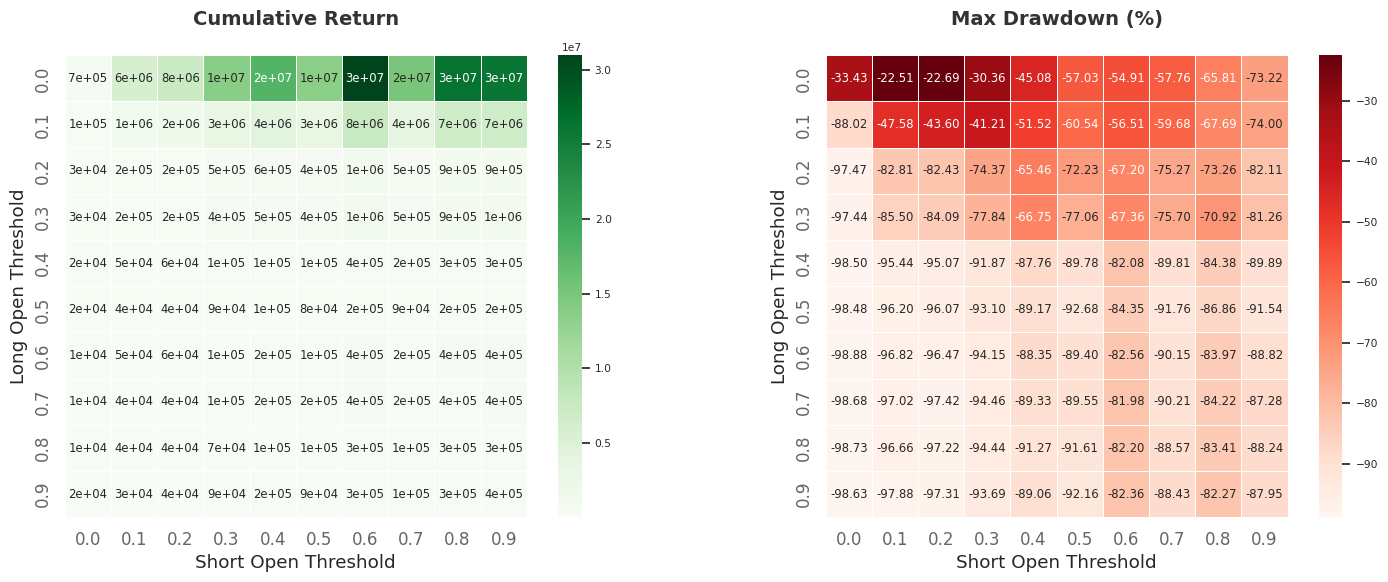

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18,6))

ax[0].set_title('Cumulative Return\n', fontsize=14, fontweight='bold')
ax[1].set_title('Max Drawdown (%)\n', fontsize=14, fontweight='bold')

reshape = lambda d: pd.DataFrame(d.values.reshape(len(d.index.levels[0]), len(d.index.levels[1])), d.index.levels[0], d.index.levels[1])

sns.set(font_scale=.7)
sns.heatmap(reshape(optimization_results['Cumulative Return']), ax=ax[0], annot=True, fmt='.0g', linewidth=.5, square=True, cmap='Greens')
sns.heatmap(reshape(optimization_results['Max Drawdown (%)']), ax=ax[1], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Reds')

plt.show()

In [10]:
best_params = optimization_results_sorted.index[0]
best_params

(np.float64(0.0), np.float64(0.6))

In [11]:
result = backtest.run(*best_params)

In [12]:
import quantstats as qs
qs.reports.metrics(result.returns, benchmark)

                    Strategy    Benchmark
------------------  ----------  -----------
Start Period        2006-01-03  2006-01-03
End Period          2026-03-16  2026-03-16
Risk-Free Rate      0.0%        0.0%
Time in Market      100.0%      100.0%

Cumulative Return   3,034.84%   1,347.49%
CAGR﹪              18.59%      14.14%

Sharpe              0.74        0.71
Prob. Sharpe Ratio  99.98%      99.93%
Sortino             1.52        1.01
Sortino/√2          1.08        0.71
Omega               1.13        1.13

Max Drawdown        -54.91%     -53.85%
Longest DD Days     1211        1161

Gain/Pain Ratio     0.13        0.14
Gain/Pain (1M)      0.81        0.89

Payoff Ratio        1.68        0.92
Profit Factor       1.13        1.14
Common Sense Ratio  3.22        1.04
CPC Index           0.78        0.58
Tail Ratio          2.85        0.92
Outlier Win Ratio   2.81        5.46
Outlier Loss Ratio  2.38        2.6

MTD                 -9.0%       -1.99%
3M                  -19.19%    

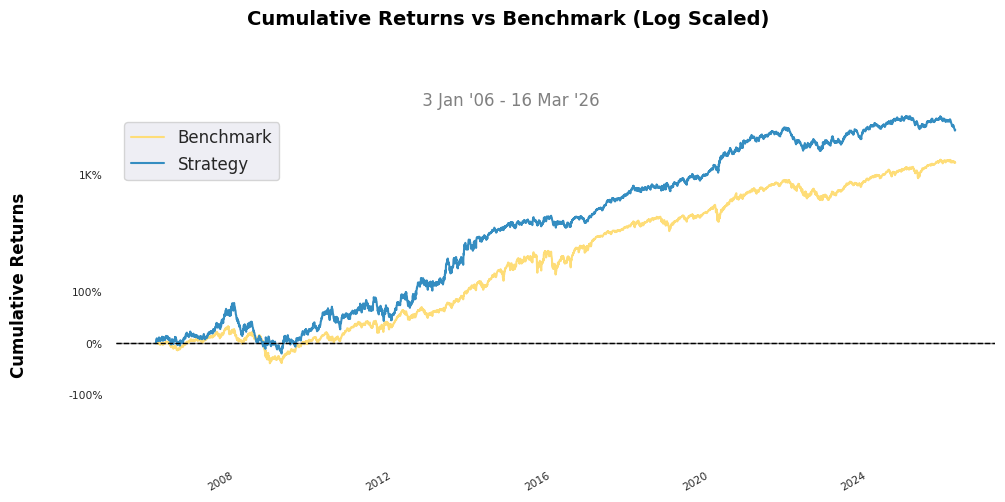

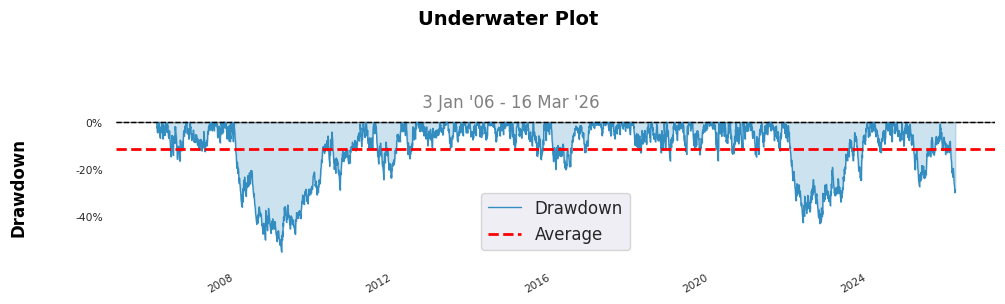

In [13]:
qs.plots.log_returns(result.returns, benchmark, fontname='sans-serif')
qs.plots.drawdown(result.returns, figsize=(10,3), fontname='sans-serif')

In [14]:
import pandas as pd

periodic_returns = result.returns.pct_change()

# Compound periodic returns into monthly returns
monthly_returns = (1 + periodic_returns).resample("ME").prod() - 1
monthly_grid = (
    monthly_returns.to_frame("Monthly Returns")
    .assign(year=lambda df: df.index.year, month=lambda df: df.index.month)
    .pivot(index="year", columns="month", values="Monthly Returns")
    .reindex(columns=range(1, 13))
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_grid.columns = month_labels

# Add yearly compounded return as the last column
yearly_returns = (1 + periodic_returns).resample("YE").prod() - 1
monthly_grid["Year"] = yearly_returns.values

# Human-readable format like 5.35%
monthly_grid_pct = monthly_grid.map(lambda x: f"{x:.2%}" if pd.notna(x) else "-")
monthly_grid_pct

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
year,,,,,,,,,,,,,
2006,8.20%,1.18%,0.83%,-2.06%,-4.40%,7.36%,-8.43%,0.17%,8.84%,4.83%,-1.22%,-0.96%,13.61%
2007,-2.33%,0.74%,-2.66%,7.11%,5.43%,1.71%,6.12%,6.51%,9.05%,6.15%,3.29%,1.59%,51.04%
2008,-18.80%,-14.65%,6.38%,2.42%,9.37%,-15.19%,-12.92%,3.01%,-8.81%,4.65%,-7.31%,6.12%,-41.02%
2009,-8.00%,-7.35%,23.47%,3.46%,-9.18%,-0.65%,6.90%,1.62%,10.08%,1.65%,2.32%,11.11%,35.76%
2010,-10.31%,7.87%,18.80%,1.59%,-3.22%,-2.38%,-3.96%,-12.79%,18.57%,0.82%,-2.95%,6.82%,14.51%
2011,0.35%,7.50%,4.29%,3.15%,-5.91%,1.38%,5.11%,-7.16%,-10.42%,11.16%,-10.00%,2.02%,-1.23%
2012,5.95%,6.56%,6.58%,5.21%,-12.27%,10.80%,4.09%,7.80%,2.81%,-4.75%,3.20%,-2.24%,36.41%
2013,-0.39%,3.83%,-0.32%,10.51%,4.60%,-2.87%,5.81%,-2.60%,2.10%,11.82%,4.33%,-3.94%,36.49%
2014,-0.02%,7.47%,-3.84%,5.67%,4.34%,4.14%,3.89%,1.03%,1.94%,3.15%,5.96%,-0.54%,38.01%


In [15]:
trades = pd.DataFrame(result.trades)
trades

,symbol,open_date,close_date,open_price,close_price,position_size,leverage,profit_loss,change_pct,trade_commission,cumulative_return
0,None,2006-01-03,2006-01-03,1658.000,1693.00,121,10.0,42350.00,2.110977,40.547100,1.042309e+06
1,None,2006-01-03,2006-01-03,1648.052,1693.00,-121,10.0,-54387.08,2.727341,40.426729,9.878819e+05
2,None,2006-01-04,2006-01-04,1694.000,1713.00,117,10.0,22230.00,1.121606,39.861900,1.010072e+06
3,None,2006-01-05,2006-01-05,1713.000,1723.00,118,10.0,11800.00,0.583771,40.544800,1.021832e+06
4,None,2006-01-06,2006-01-06,1722.500,1748.00,119,10.0,30345.00,1.480406,41.298950,1.052135e+06
...,...,...,...,...,...,...,...,...,...,...,...
7677,None,2026-03-12,2026-03-12,24934.500,24560.00,250,10.0,-936250.00,-1.501935,1237.362500,3.022618e+07
7678,None,2026-03-12,2026-03-12,24784.893,24560.00,-251,10.0,564481.43,-0.907379,1238.556814,3.078943e+07
7679,None,2026-03-13,2026-03-13,24567.000,24394.25,251,10.0,-433602.50,-0.703179,1228.927375,3.035460e+07
7680,None,2026-03-13,2026-03-13,24419.598,24394.25,-252,10.0,63876.96,-0.103802,1230.108970,3.041724e+07


In [ ]:
remaining_positions = pd.DataFrame(result.open_positions)
remaining_positions

""
